# PageRank

## Library

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re, sys, time
from urllib.parse import urljoin, urlparse
import urllib3
import networkx as nx
import matplotlib.pyplot as plt

## Crawling Link (https://informatika.trunojoyo.ac.id/)

In [ ]:
def print_progress2(kategori, current_page, total_pages):
    percent = (current_page / total_pages) * 100
    bar_length = 20
    filled_length = int(bar_length * current_page // total_pages)
    bar = '█' * filled_length + '-' * (bar_length - filled_length)
    sys.stdout.write(f'\r{kategori} - Page {current_page}/{total_pages} [{bar}] {percent:.2f}%')
    sys.stdout.flush()
    if current_page == total_pages:
        sys.stdout.write('\n\n')

In [ ]:
# matikan warning SSL insecure
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

def scrape_all_links(base_url, max_pages=50):
    visited = set()
    results = []
    current_page = 0

    def scrape_page(url):
        nonlocal current_page
        try:
            response = requests.get(url, verify=False, timeout=10)
            soup = BeautifulSoup(response.text, 'html.parser')

            # ambil semua link keluar
            for a in soup.find_all('a', href=True):
                href = a['href'].strip()
                if not href or href == "#":
                    continue
                full_link = urljoin(url, href)
                results.append({
                    "Page": url,
                    "Link Keluar": full_link
                })

            # update progress setiap selesai 1 page
            current_page += 1
            print_progress2("Scraping", current_page, max_pages)

            # cari link internal untuk dilanjutkan
            for a in soup.find_all('a', href=True):
                href = a['href'].strip()
                if not href or href == "#":
                    continue
                full_link = urljoin(url, href)
                # hanya ambil link internal
                if full_link.startswith(base_url) and full_link not in visited:
                    visited.add(full_link)
                    if len(visited) < max_pages:
                        scrape_page(full_link)

        except Exception as e:
            print(f"⚠️ Gagal akses {url}: {e}")

    # mulai dari base_url
    visited.add(base_url)
    scrape_page(base_url)

    # rapikan dataframe dan simpan CSV
    df = pd.DataFrame(results).reset_index(drop=True)
    df.index += 1
    df.insert(0, "No", df.index)
    df.to_csv("link.csv", index=False, encoding="utf-8-sig")

    print("\n✅ Seluruh data berhasil dikumpulkan!")
    print(f"📊 Total entri: {len(df)}")

    return None

In [ ]:
url = "https://informatika.trunojoyo.ac.id/"
scrape_all_links(url, max_pages=50)

Scraping - Page 49/50 [███████████████████-] 98.00%
✅ Seluruh data berhasil dikumpulkan!
📊 Total entri: 2588


In [ ]:
link = pd.read_csv("link.csv")
link

,No,Page,Link Keluar
0,1,https://informatika.trunojoyo.ac.id/,https://informatika.trunojoyo.ac.id/
1,2,https://informatika.trunojoyo.ac.id/,https://informatika.trunojoyo.ac.id/bidang-min...
2,3,https://informatika.trunojoyo.ac.id/,https://informatika.trunojoyo.ac.id/bidang-min...
3,4,https://informatika.trunojoyo.ac.id/,https://informatika.trunojoyo.ac.id/bidang-min...
4,5,https://informatika.trunojoyo.ac.id/,https://informatika.trunojoyo.ac.id/bidang-min...
...,...,...,...
2583,2584,https://informatika.trunojoyo.ac.id/berita-lab...,https://www.instagram.com/tifutm.official
2584,2585,https://informatika.trunojoyo.ac.id/berita-lab...,https://youtube.com/@teknikinformatikautm
2585,2586,https://informatika.trunojoyo.ac.id/berita-lab...,https://informatika.trunojoyo.ac.id/berita-lab...
2586,2587,https://informatika.trunojoyo.ac.id/berita-lab...,https://informatika.trunojoyo.ac.id/berita-lab...


## PageRank

### Persiapan Data

In [ ]:
# === 1. Gunakan data 'link' yang sudah dibaca ===
# Pastikan kolom: 'Page' (asal), 'Link Keluar' (tujuan)
edges = link[['Page', 'Link Keluar']].copy()

# Tentukan node unik
nodes = pd.Index(sorted(set(edges['Page']).union(edges['Link Keluar'])))
n = len(nodes)
print(f"Jumlah node: {n}")

# Buat mapping node → index
node_to_index = {node: i for i, node in enumerate(nodes)}

Jumlah node: 177


### Pembentukan Node dan Matriks Adjacency

In [ ]:
# === 2. Bangun matriks adjacency ===
A = np.zeros((n, n), dtype=float)
for _, row in edges.iterrows():
    i = node_to_index[row['Page']]
    j = node_to_index[row['Link Keluar']]
    A[j, i] = 1  # arah Page → Link Keluar

### Normalisasi Matriks (Stochastic Matrix)

In [ ]:
# === 3. Normalisasi kolom (stochastic matrix) ===
col_sums = A.sum(axis=0)
for j in range(n):
    if col_sums[j] == 0:
        A[:, j] = 1.0 / n    # dangling node → teleportasi penuh
    else:
        A[:, j] /= col_sums[j]

### Iterasi PageRank

In [ ]:
# === 4. Inisialisasi dan iterasi PageRank ===
r = np.ones(n) / n
d = 0.85
epsilon = 1e-6
iteration = 0

while True:
    r_new = d * A @ r + (1 - d) / n
    diff = np.linalg.norm(r_new - r, 1)
    iteration += 1
    print(f"Iterasi {iteration}: diff = {diff:.8f}")
    if diff < epsilon:
        break
    r = r_new

Iterasi 1: diff = 0.27901990
Iterasi 2: diff = 0.11054526
Iterasi 3: diff = 0.04375425
Iterasi 4: diff = 0.01731761
Iterasi 5: diff = 0.00685418
Iterasi 6: diff = 0.00271283
Iterasi 7: diff = 0.00107372
Iterasi 8: diff = 0.00042497
Iterasi 9: diff = 0.00016820
Iterasi 10: diff = 0.00006657
Iterasi 11: diff = 0.00002635
Iterasi 12: diff = 0.00001043
Iterasi 13: diff = 0.00000413
Iterasi 14: diff = 0.00000163
Iterasi 15: diff = 0.00000065


### Hasil PageRank

In [ ]:
# === 5. Hasil PageRank ===
Pagerank_df = pd.DataFrame({
    'Page': nodes,
    'PageRank': r
}).sort_values(by='PageRank', ascending=False)

print("Top 5 page dengan PageRank tertinggi:")
Pagerank_df.head(5)

Top 5 page dengan PageRank tertinggi:


,Page,PageRank
0,http://himatif.trunojoyo.ac.id/,0.01038
6,https://informatika.trunojoyo.ac.id/berita,0.01038
5,https://informatika.trunojoyo.ac.id/,0.01038
35,https://informatika.trunojoyo.ac.id/dokumen-mu...,0.01038
37,https://informatika.trunojoyo.ac.id/dokumen-so...,0.01038


## Visualisasi Hasil PageRank

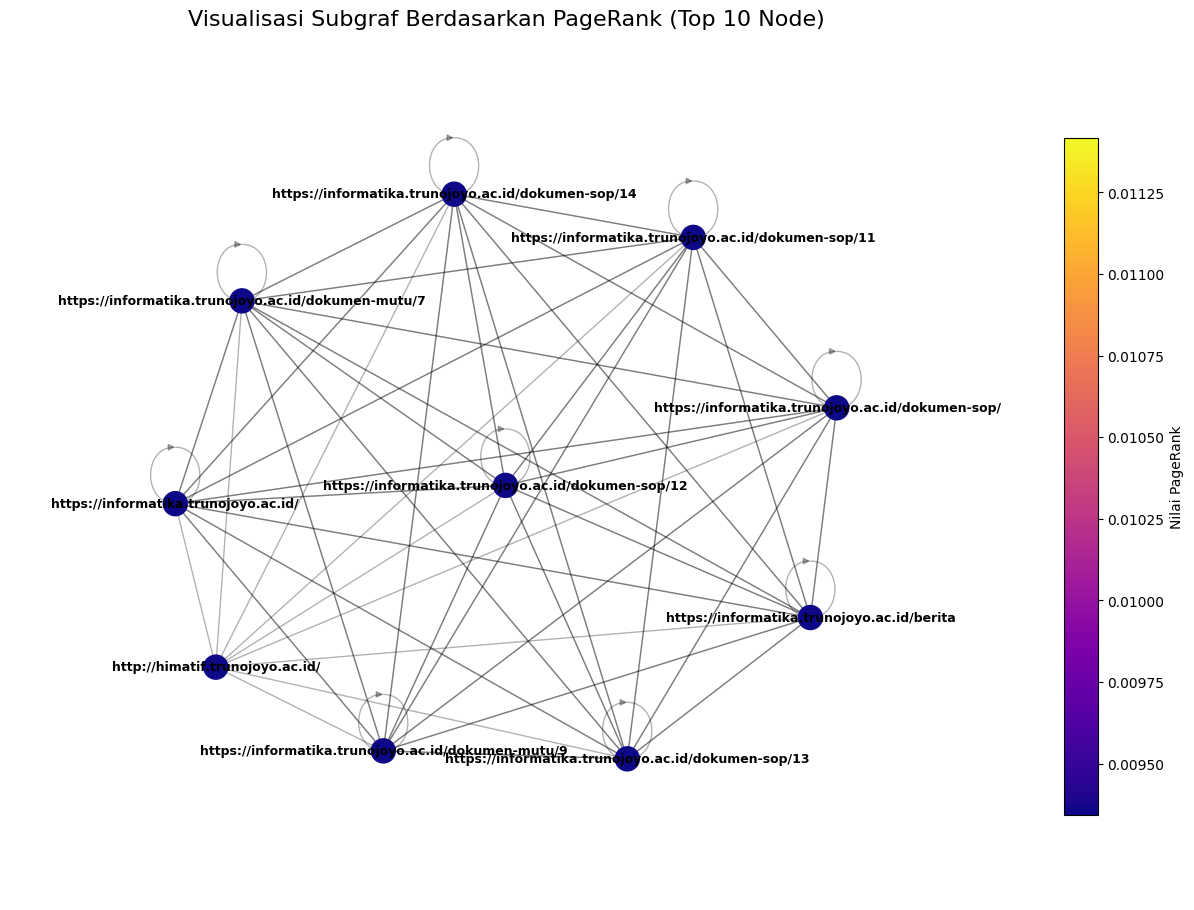

In [ ]:
# === 6. Buat Graph untuk Visualisasi ===
edges_viz = edges.rename(columns={'Page': 'From', 'Link Keluar': 'To'})
G = nx.DiGraph()
G.add_edges_from(edges_viz.itertuples(index=False, name=None))

# Ambil 10 node dengan PageRank tertinggi
top_nodes = Pagerank_df.head(10)['Page'].tolist()
H = G.subgraph(top_nodes).copy()

# Warna berdasarkan nilai PageRank
pr_sub = dict(zip(Pagerank_df['Page'], Pagerank_df['PageRank']))
node_colors = [pr_sub.get(n, 0) for n in H.nodes()]

# === 7. Visualisasi Graf ===
fig, ax = plt.subplots(figsize=(16, 11))
pos = nx.kamada_kawai_layout(H)

# Gambar node dan edge
nx.draw_networkx_nodes(
    H, pos,
    node_color=node_colors,
    cmap=plt.cm.plasma,
    node_size=300,
    ax=ax
)
nx.draw_networkx_edges(H, pos, alpha=0.3, arrows=False, ax=ax)

# Tambahkan label node
nx.draw_networkx_labels(
    H, pos,
    font_size=9,
    font_color='black',
    font_weight='bold',
    verticalalignment='center',
    horizontalalignment='center',
    ax=ax
)

# Hitung batas posisi node untuk perluasan area gambar
x_values = [p[0] for p in pos.values()]
y_values = [p[1] for p in pos.values()]
x_margin = (max(x_values) - min(x_values)) * 0.25
y_margin = (max(y_values) - min(y_values)) * 0.25

ax.set_xlim(min(x_values) - x_margin, max(x_values) + x_margin)
ax.set_ylim(min(y_values) - y_margin, max(y_values) + y_margin)

# Tambahkan judul dan colorbar
ax.set_title("Visualisasi Subgraf Berdasarkan PageRank (Top 10 Node)", fontsize=16, pad=20)
ax.axis("off")

sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma)
sm.set_array(node_colors)
plt.colorbar(sm, label="Nilai PageRank", ax=ax, shrink=0.8)

plt.show()